In [1]:
from core.em_project import EMProject
import matplotlib.pyplot as plt
%matplotlib widget

# 1. Start project
project_name = 'multi_tesla'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

# 2. Create assembly
assembly = proj.create_assembly(main_axis='Z')

# 3. Create importers for your files
# (The code automatically loads the CAD data)
cav1 = proj.create_importer("./tesla1cell.iges", unit='mm')
cav2 = proj.create_importer("./tesla1cell.iges", unit='mm')

# 4. Add them to the assembly
# Assembly will automatically align them based on their bounding boxes
assembly.add("cavity1", cav1)
assembly.add("cavity2", cav2, after="cavity1")

# 5. Build and mesh the whole assembly
assembly.build()
assembly.generate_mesh(maxh=0.1)
# assembly.show('mesh')
proj.geo.show('mesh')

Creating new project 'multi_tesla' at C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Port naming complete:
  Total ports: 3
  External ports: 2
  Interface ports: 1


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [2]:
fom_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 2,
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct',
    # 'iterative_opts': {
    #     'precond': 'bddc',
    #     'maxsteps': 500,
    # },
    # 'rerun': True
}
fom_result = proj.fds.solve(config=fom_config)

INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Compound structure
INFO:: Domains (2): ['cavity1', 'cavity2']
INFO:: Total Ports (3): ['port1', 'port2', 'port3']
INFO:: External Ports (2): ['port1', 'port3']
INFO:: Internal Ports (1): ['port2']
INFO:: 
Domain-Port Mapping:
  cavity1: ['port1 (external, input)', 'port2 (internal)']
  cavity2: ['port2 (internal)', 'port3 (external, output)']
INFO::   No valid results found. Forcing compute. (Z_coupled=False, foms=False, fmin=None)

Assembling Matrices...
Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: circular (fit error: 0.0000)
	    R=0.035002
	  port2: circular (fit error: 0.0000)
	    R=0.035002
	  port3: circular (fit error: 0.0000)
	    R=0.035002
	  Precomputing boundary mass matrices (once per port)

Loaded CST S-parameters from: tesla1cell_double
  Frequency range: 0.0010 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


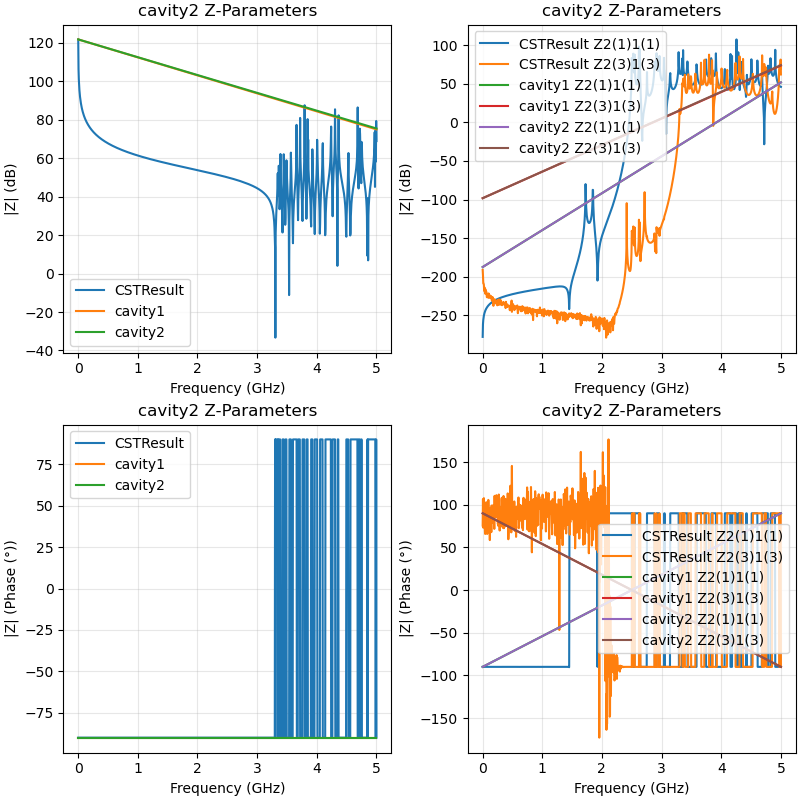

In [3]:
from analytical.cst_result import CSTResult
%matplotlib widget

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell_double')
# plot comparison
which = [['1(3)1(3)'], ['2(1)1(1)', '2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1])
    proj.fds.foms.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.foms.plot_z(wh, plot_type='phase', ax=axs[idx+3])

In [4]:
# Reduce model order
roms = proj.fds.foms.reduce(tol=1e-15)
# concat = proj.fds.fom.rom.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    # 'rerun': True
}
rom_result = roms.solve(config=roms_config) # solve reduced order model on more frequency samples



Model Order Reduction
INFO:: 
Domain: cavity1
INFO:: 
Domain: cavity2
Total: 525876 → 24 DOFs
Overall compression: 100.0%
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds
INFO:: 
Coupled unified system: 24 -> 21 DOFs
  Solve: 0.014s (1000 frequencies)


Loaded CST S-parameters from: tesla1cell_double
  Frequency range: 0.0010 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


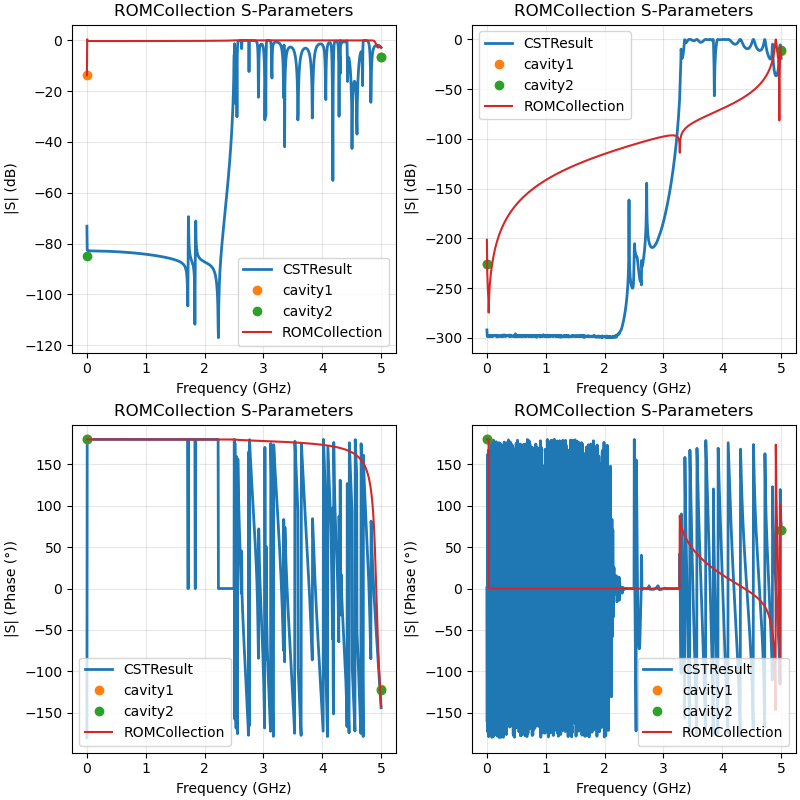

In [5]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell_double')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=2)
    proj.fds.foms.plot_s(wh, ax=axs[idx+1], marker='o', lw=0)
    roms.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=2)
    (proj.fds.
     foms.plot_s(wh, plot_type='phase', ax=axs[idx+3], marker='o', lw=0))
    roms.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

In [6]:
concat = proj.fds.foms.roms.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1001, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct', # <- changed to direct method, faster for smaller matrices
    'rerun': True
}
concat_result = concat.solve(config=roms_config) # solve reduced order model on more frequency samples

INFO:: 
Coupled unified system: 24 -> 21 DOFs
  Solve: 0.012s (1001 frequencies)


Loaded CST S-parameters from: tesla1cell_double
  Frequency range: 0.0010 - 5.0000 GHz (1001 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


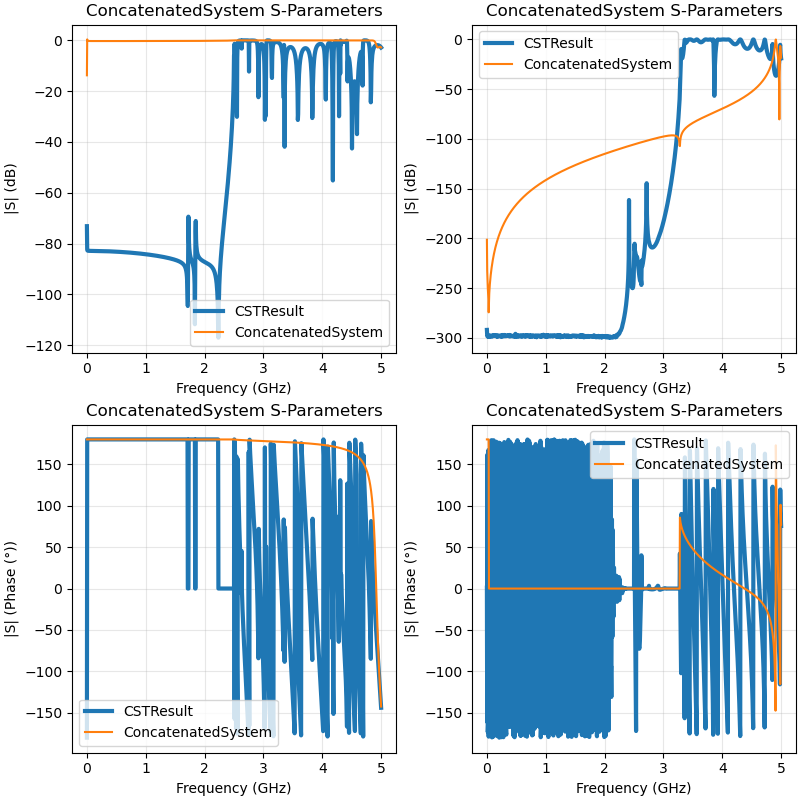

In [7]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell_double')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=3)
    concat.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    concat.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

  Note: cavity1 residuals are zero. This is expected when using a direct solver (solver_type='direct').
  Note: cavity2 residuals are zero. This is expected when using a direct solver (solver_type='direct').


(<Figure size 600x600 with 2 Axes>,
 (<Axes: title={'center': 'Per-Domain Iterative Solver Convergence'}, xlabel='Frequency (GHz)', ylabel='GMRES Iterations'>,
  <Axes: ylabel='Relative Residual'>))

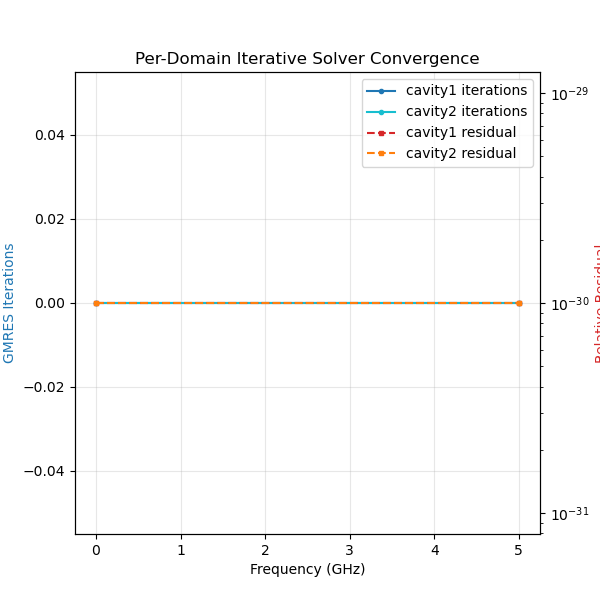

In [8]:
proj.fds.foms.plot_residual(figsize=(6, 6))

In [9]:
concat.get_eigenmodes()

C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\multi_tesla\fds\foms\roms\concat\eigenmodes\eigenmodes.h5


(array([1.22029719e+06, 1.89190874e+06, 2.24027798e+06, 1.08190505e+14,
        1.10761585e+14, 1.24160649e+14, 1.28693828e+14, 4.83450728e+20,
        4.83471241e+20, 9.49723856e+20, 9.49748131e+20, 9.51417916e+20,
        9.61521263e+20, 9.61534597e+20, 9.79480975e+20, 9.81633045e+20,
        9.85838465e+20, 1.01054182e+21, 1.01055705e+21, 1.05868207e+21,
        1.05869682e+21]),
 array([[-2.19922777e-03+0.j, -6.79886279e-04+0.j,  1.99567190e-02+0.j,
         -5.21391982e-10+0.j, -1.11128530e-01+0.j, -4.32567790e-10+0.j,
          2.48976217e-02+0.j,  1.63003137e-02+0.j,  3.13626029e-03+0.j,
         -1.19195601e-01+0.j,  8.26550689e-02+0.j, -4.65425334e-02+0.j,
         -3.08263670e-01+0.j,  6.98843980e-02+0.j,  2.85653443e-01+0.j,
         -3.32321682e-01+0.j, -1.69268722e-01+0.j, -5.84410139e-01+0.j,
         -1.16746884e-01+0.j, -1.06393252e-01+0.j, -5.25417372e-01+0.j],
        [-1.84326840e-02+0.j, -7.92869761e-04+0.j,  1.08932891e-02+0.j,
          1.37029585e-10+0.j,  5.3869

In [10]:
concat.plot_eigenmode(19)

INFO:: 
Eigenmode 19 at f = 5.1785 GHz


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'camera': {'euler_angles': […

In [11]:
# """
# Test script for multi-domain field reconstruction in NGSolve.

# This script demonstrates:
# 1. Creating a split waveguide geometry (two subdomains)
# 2. Solving eigenvalue problems on each subdomain independently
# 3. Correctly reconstructing fields on the global domain WITHOUT overwriting
# """

# from ngsolve import *
# from ngsolve.webgui import Draw
# from netgen.occ import *
# import numpy as np

# # ============================================================================
# # GEOMETRY: Two connected rectangular waveguide sections
# # ============================================================================

# def create_split_waveguide_geometry(
#     length1: float = 1.0,
#     length2: float = 2.0,
#     width: float = 0.5,
#     height: float = 0.3,
#     mesh_size: float = 0.1
# ):
#     """
#     Create a waveguide split into two domains with a shared interface.
#     """
#     # Create two boxes
#     box1 = Box(Pnt(0, 0, 0), Pnt(length1, width, height))
#     box1.name = "domain1"
#     box1.mat("domain1")

#     box2 = Box(Pnt(length1, 0, 0), Pnt(length1 + length2, width, height))
#     box2.name = "domain2"
#     box2.mat("domain2")

#     # Name faces for boundary conditions
#     box1.faces.Min(X).name = "port1"
#     box1.faces.Max(X).name = "interface"
#     box1.faces.Min(Y).name = "wall"
#     box1.faces.Max(Y).name = "wall"
#     box1.faces.Min(Z).name = "wall"
#     box1.faces.Max(Z).name = "wall"

#     box2.faces.Min(X).name = "interface"
#     box2.faces.Max(X).name = "port2"
#     box2.faces.Min(Y).name = "wall"
#     box2.faces.Max(Y).name = "wall"
#     box2.faces.Min(Z).name = "wall"
#     box2.faces.Max(Z).name = "wall"

#     # Glue them together
#     shape = Glue([box1, box2])

#     # Generate mesh
#     geo = OCCGeometry(shape)
#     ngmesh = geo.GenerateMesh(maxh=mesh_size)
#     mesh = Mesh(ngmesh)

#     return mesh


# def get_element_material_map(mesh):
#     """Build element index -> material name mapping."""
#     mat_names = list(mesh.GetMaterials())
#     print(f"   Materials in mesh: {mat_names}")

#     el_to_mat = {}
#     mat_to_els = {m: [] for m in mat_names}

#     # el.mat returns the material name directly as a string
#     for el in mesh.Elements(VOL):
#         el_idx = el.nr
#         mat_name = el.mat  # This is already a string
#         el_to_mat[el_idx] = mat_name
#         if mat_name in mat_to_els:
#             mat_to_els[mat_name].append(el_idx)

#     for mat_name in mat_names:
#         print(f"   {mat_name}: {len(mat_to_els[mat_name])} elements")

#     return el_to_mat, mat_names, mat_to_els


# def get_domain_elements(mesh, domain_name):
#     """Get list of element indices belonging to a domain."""
#     elements = []
#     for el in mesh.Elements(VOL):
#         if el.mat == domain_name:
#             elements.append(el.nr)
#     return elements


# # ============================================================================
# # EIGENVALUE SOLVER
# # ============================================================================

# def solve_maxwell_eigenvalue_on_domain(fes, mesh, domain_name: str, n_modes: int = 5):
#     """
#     Solve Maxwell eigenvalue problem restricted to a domain.
#     """
#     u, v = fes.TnT()

#     # Restrict to subdomain
#     region = mesh.Materials(domain_name)

#     a = BilinearForm(fes)
#     a += curl(u) * curl(v) * dx(definedon=region)

#     m = BilinearForm(fes)
#     m += u * v * dx(definedon=region)

#     a.Assemble()
#     m.Assemble()

#     # Get freedofs
#     freedofs = fes.FreeDofs()

#     # Find DOFs with support in this domain
#     domain_dofs = set()
#     for el in mesh.Elements(VOL):
#         if el.mat == domain_name:
#             for d in fes.GetDofNrs(el):
#                 if d >= 0 and freedofs[d]:
#                     domain_dofs.add(d)

#     domain_dof_list = sorted(domain_dofs)
#     n_domain_dofs = len(domain_dof_list)
#     n_elements = len([el for el in mesh.Elements(VOL) if el.mat == domain_name])
#     print(f"     Domain '{domain_name}': {n_domain_dofs} active DOFs, {n_elements} elements")

#     if n_domain_dofs == 0:
#         raise ValueError(f"No DOFs found in domain '{domain_name}'")

#     # Extract submatrices for domain DOFs only
#     A_dense = np.zeros((n_domain_dofs, n_domain_dofs), dtype=complex)
#     M_dense = np.zeros((n_domain_dofs, n_domain_dofs), dtype=complex)

#     tmp1 = GridFunction(fes)
#     tmp2 = GridFunction(fes)

#     for i, di in enumerate(domain_dof_list):
#         tmp1.vec[:] = 0
#         tmp1.vec[di] = 1

#         tmp2.vec.data = a.mat * tmp1.vec
#         for j, dj in enumerate(domain_dof_list):
#             A_dense[j, i] = tmp2.vec[dj]

#         tmp2.vec.data = m.mat * tmp1.vec
#         for j, dj in enumerate(domain_dof_list):
#             M_dense[j, i] = tmp2.vec[dj]

#     # Regularize M if needed
#     M_dense += 1e-14 * np.eye(n_domain_dofs)

#     # Solve generalized eigenvalue problem
#     from scipy.linalg import eigh
#     eigenvalues, eigenvectors = eigh(A_dense, M_dense)

#     # Filter out zero/negative eigenvalues
#     valid_idx = eigenvalues > 1e-6
#     eigenvalues = eigenvalues[valid_idx]
#     eigenvectors = eigenvectors[:, valid_idx]

#     if len(eigenvalues) == 0:
#         raise ValueError(f"No valid eigenvalues found for domain '{domain_name}'")

#     # Sort and take first n_modes
#     sort_idx = np.argsort(eigenvalues)[:n_modes]
#     eigenvalues = eigenvalues[sort_idx]
#     eigenvectors = eigenvectors[:, sort_idx]

#     # Convert to GridFunctions
#     gf_modes = []
#     for k in range(min(n_modes, eigenvectors.shape[1])):
#         gf = GridFunction(fes, complex=True)
#         gf.vec[:] = 0
#         for i, di in enumerate(domain_dof_list):
#             gf.vec[di] = eigenvectors[i, k]
#         gf_modes.append(gf)

#     return eigenvalues, gf_modes, domain_dof_list


# # ============================================================================
# # FIELD RECONSTRUCTION METHODS
# # ============================================================================

# def reconstruct_naive(fes, mesh, gf_list, domain_names):
#     """
#     NAIVE reconstruction using Set with definedon.
#     This demonstrates the overwriting problem.
#     """
#     E_global = GridFunction(fes, complex=True)
#     E_global.vec[:] = 0

#     for gf, domain_name in zip(gf_list, domain_names):
#         region = mesh.Materials(domain_name)
#         E_global.Set(gf, definedon=region)

#     return E_global


# def reconstruct_direct_dof(fes, mesh, gf_list, domain_names, domain_dof_lists, scales=None):
#     """
#     CORRECT reconstruction using direct DOF assignment.
#     """
#     if scales is None:
#         scales = [1.0] * len(gf_list)

#     E_global = GridFunction(fes, complex=True)
#     global_vec = E_global.vec.FV().NumPy()
#     global_vec[:] = 0

#     # Track contributions to each DOF
#     dof_values = np.zeros(fes.ndof, dtype=complex)
#     dof_counts = np.zeros(fes.ndof, dtype=int)

#     for gf, domain_dofs, scale in zip(gf_list, domain_dof_lists, scales):
#         local_vec = gf.vec.FV().NumPy()

#         for dof in domain_dofs:
#             dof_values[dof] += scale * local_vec[dof]
#             dof_counts[dof] += 1

#     # Assign values (average at interfaces)
#     for dof in range(fes.ndof):
#         if dof_counts[dof] > 0:
#             global_vec[dof] = dof_values[dof] / dof_counts[dof]

#     n_interface = np.sum(dof_counts > 1)
#     print(f"     Direct DOF: {np.sum(dof_counts > 0)} DOFs set, {n_interface} interface DOFs")

#     return E_global


# def reconstruct_element_wise(fes, mesh, gf_list, domain_names, scales=None,
#                              interface_mode='average'):
#     """
#     Element-wise reconstruction with explicit interface handling.
#     """
#     if scales is None:
#         scales = [1.0] * len(gf_list)

#     E_global = GridFunction(fes, complex=True)
#     global_vec = E_global.vec.FV().NumPy()
#     global_vec[:] = 0

#     # Track contributions
#     dof_contributions = {}

#     for idx, (gf, domain_name, scale) in enumerate(zip(gf_list, domain_names, scales)):
#         local_vec = gf.vec.FV().NumPy()

#         for el in mesh.Elements(VOL):
#             if el.mat != domain_name:
#                 continue

#             for dof in fes.GetDofNrs(el):
#                 if dof < 0:
#                     continue

#                 if dof not in dof_contributions:
#                     dof_contributions[dof] = []

#                 # Check if this domain already contributed
#                 already = any(d_idx == idx for d_idx, _ in dof_contributions[dof])
#                 if not already:
#                     dof_contributions[dof].append((idx, scale * local_vec[dof]))

#     # Assign values
#     n_interface = 0
#     for dof, contributions in dof_contributions.items():
#         if len(contributions) == 1:
#             global_vec[dof] = contributions[0][1]
#         else:
#             n_interface += 1
#             if interface_mode == 'average':
#                 global_vec[dof] = np.mean([c[1] for c in contributions])
#             elif interface_mode == 'first':
#                 global_vec[dof] = contributions[0][1]
#             elif interface_mode == 'last':
#                 global_vec[dof] = contributions[-1][1]

#     print(f"     Element-wise ({interface_mode}): {len(dof_contributions)} DOFs, {n_interface} interface DOFs")

#     return E_global


# # ============================================================================
# # INTERFACE SCALING
# # ============================================================================

# def compute_interface_scale(gf1, gf2, dofs1, dofs2, fes):
#     """
#     Compute scaling factor using shared interface DOFs.
#     """
#     interface_dofs = set(dofs1) & set(dofs2)
#     print(f"     Found {len(interface_dofs)} interface DOFs")

#     if not interface_dofs:
#         return 1.0, 1.0

#     vec1 = gf1.vec.FV().NumPy()
#     vec2 = gf2.vec.FV().NumPy()

#     vals1 = np.array([vec1[d] for d in interface_dofs])
#     vals2 = np.array([vec2[d] for d in interface_dofs])

#     # Filter near-zero
#     mask = (np.abs(vals1) > 1e-12) | (np.abs(vals2) > 1e-12)
#     if not np.any(mask):
#         return 1.0, 1.0

#     vals1 = vals1[mask]
#     vals2 = vals2[mask]

#     # Least squares: scale * vals2 ≈ vals1
#     denom = np.vdot(vals2, vals2)
#     if abs(denom) < 1e-14:
#         return 1.0, 1.0

#     scale = np.vdot(vals2, vals1) / denom

#     mismatch_before = np.linalg.norm(vals1 - vals2) / (np.linalg.norm(vals1) + 1e-14)
#     mismatch_after = np.linalg.norm(vals1 - scale * vals2) / (np.linalg.norm(vals1) + 1e-14)

#     print(f"     Scale: {abs(scale):.4f} ∠{np.angle(scale)*180/np.pi:.1f}°")
#     print(f"     Mismatch: {mismatch_before:.2%} → {mismatch_after:.2%}")

#     return scale, mismatch_after


# # ============================================================================
# # DIAGNOSTICS
# # ============================================================================

# def compute_domain_norms(gf, mesh, domain_names):
#     """Compute |E|² in each domain."""
#     norms = {}
#     for domain_name in domain_names:
#         region = mesh.Materials(domain_name)
#         norm_sq = Integrate(InnerProduct(gf, gf), mesh, definedon=region)
#         norms[domain_name] = abs(norm_sq)
#     return norms


# def compare_interface_dofs(gf1, gf2, interface_dofs, n_show=10):
#     """Compare field values at interface DOFs."""
#     vec1 = gf1.vec.FV().NumPy()
#     vec2 = gf2.vec.FV().NumPy()

#     print(f"\n     Interface DOF comparison (first {n_show}):")
#     print(f"     {'DOF':>6} | {'gf1':>24} | {'gf2':>24} | {'diff':>12}")
#     print("     " + "-" * 75)

#     for i, dof in enumerate(sorted(interface_dofs)[:n_show]):
#         v1, v2 = vec1[dof], vec2[dof]
#         diff = abs(v1 - v2)
#         print(f"     {dof:>6} | {v1.real:>11.3e}{v1.imag:+11.3e}j | {v2.real:>11.3e}{v2.imag:+11.3e}j | {diff:>12.2e}")


# # ============================================================================
# # MAIN TEST
# # ============================================================================

# def run_test():
#     """Main test function."""
#     print("=" * 70)
#     print("MULTI-DOMAIN FIELD RECONSTRUCTION TEST")
#     print("=" * 70)

#     # 1. Create geometry
#     print("\n1. Creating split waveguide geometry...")
#     mesh = create_split_waveguide_geometry(
#         length1=1.0, length2=3.0,
#         width=0.5, height=0.3,
#         mesh_size=0.15
#     )
#     print(f"   Elements: {mesh.ne}, Vertices: {mesh.nv}")

#     # Get materials
#     el_to_mat, mat_names, mat_to_els = get_element_material_map(mesh)

#     # 2. Create FE space
#     print("\n2. Creating finite element space...")
#     order = 2
#     fes = HCurl(mesh, order=order, complex=True, dirichlet="wall")
#     print(f"   FES: {fes.ndof} DOFs, order={order}")

#     # 3. Solve eigenvalue problems
#     print("\n3. Solving eigenvalue problems on each domain...")

#     print("   Domain 1:")
#     eigs1, modes1, dofs1 = solve_maxwell_eigenvalue_on_domain(fes, mesh, "domain1", n_modes=3)
#     print(f"     Eigenvalues: {eigs1[:3]}")

#     print("\n   Domain 2:")
#     eigs2, modes2, dofs2 = solve_maxwell_eigenvalue_on_domain(fes, mesh, "domain2", n_modes=3)
#     print(f"     Eigenvalues: {eigs2[:3]}")

#     # Find interface DOFs
#     interface_dofs = set(dofs1) & set(dofs2)
#     print(f"\n   Interface DOFs: {len(interface_dofs)}")

#     # 4. Test naive reconstruction
#     print("\n4. Testing NAIVE reconstruction (Set with definedon)...")
#     E_naive = reconstruct_naive(fes, mesh, [modes1[0], modes2[0]], ["domain1", "domain2"])
#     norms_naive = compute_domain_norms(E_naive, mesh, ["domain1", "domain2"])
#     print(f"   Norms: domain1={norms_naive['domain1']:.4e}, domain2={norms_naive['domain2']:.4e}")

#     # 5. Test direct DOF reconstruction
#     print("\n5. Testing DIRECT DOF reconstruction...")
#     E_direct = reconstruct_direct_dof(
#         fes, mesh,
#         [modes1[0], modes2[0]],
#         ["domain1", "domain2"],
#         [dofs1, dofs2]
#     )
#     norms_direct = compute_domain_norms(E_direct, mesh, ["domain1", "domain2"])
#     print(f"   Norms: domain1={norms_direct['domain1']:.4e}, domain2={norms_direct['domain2']:.4e}")

#     # 6. Test element-wise reconstruction
#     print("\n6. Testing ELEMENT-WISE reconstruction with different interface handling...")
#     norms_elem = {}
#     for mode in ['first', 'average', 'last']:
#         E_elem = reconstruct_element_wise(
#             fes, mesh,
#             [modes1[0], modes2[0]],
#             ["domain1", "domain2"],
#             interface_mode=mode
#         )
#         norms = compute_domain_norms(E_elem, mesh, ["domain1", "domain2"])
#         norms_elem[mode] = norms
#         print(f"   {mode:>8}: domain1={norms['domain1']:.4e}, domain2={norms['domain2']:.4e}")

#     # 7. Compute interface scaling
#     print("\n7. Computing interface scaling...")
#     scale, mismatch = compute_interface_scale(modes1[0], modes2[0], dofs1, dofs2, fes)

#     # 8. Reconstruct with scaling
#     print("\n8. Reconstruction WITH scaling...")
#     E_scaled = reconstruct_direct_dof(
#         fes, mesh,
#         [modes1[0], modes2[0]],
#         ["domain1", "domain2"],
#         [dofs1, dofs2],
#         scales=[1.0, scale]
#     )
#     norms_scaled = compute_domain_norms(E_scaled, mesh, ["domain1", "domain2"])
#     print(f"   Norms: domain1={norms_scaled['domain1']:.4e}, domain2={norms_scaled['domain2']:.4e}")

#     # 9. Interface analysis
#     print("\n9. Interface DOF analysis...")
#     compare_interface_dofs(modes1[0], modes2[0], interface_dofs)

#     # 10. Visualize
#     print("\n10. Visualization...")
#     Draw(Norm(modes1[0]), mesh, "mode1_domain1")
#     Draw(Norm(modes2[0]), mesh, "mode2_domain2")
#     Draw(Norm(E_naive), mesh, "E_naive")
#     Draw(Norm(E_direct), mesh, "E_direct")
#     Draw(Norm(E_scaled), mesh, "E_scaled")

#     # Summary
#     print("\n" + "=" * 70)
#     print("SUMMARY")
#     print("=" * 70)
#     print(f"{'Method':<25} | {'domain1':>15} | {'domain2':>15} | {'ratio':>10}")
#     print("-" * 70)

#     results_table = [
#         ("Naive (Set/definedon)", norms_naive),
#         ("Direct DOF (average)", norms_direct),
#         ("Element-wise (first)", norms_elem['first']),
#         ("Element-wise (average)", norms_elem['average']),
#         ("Element-wise (last)", norms_elem['last']),
#         ("Direct DOF + scaling", norms_scaled),
#     ]

#     for name, norms in results_table:
#         n1, n2 = norms['domain1'], norms['domain2']
#         ratio = n2 / n1 if n1 > 1e-15 else float('inf')
#         print(f"{name:<25} | {n1:>15.4e} | {n2:>15.4e} | {ratio:>10.4f}")

#     # Diagnostic
#     print("\n" + "-" * 70)
#     if norms_naive['domain1'] < 1e-10 or norms_naive['domain2'] < 1e-10:
#         lost = 'domain1' if norms_naive['domain1'] < 1e-10 else 'domain2'
#         print(f"⚠️  NAIVE method lost field in {lost}!")
#         print("   This confirms the Set() overwriting problem.")
#     else:
#         print("ℹ️  Naive method preserved both domains (may work for non-overlapping DOFs)")

#     if norms_direct['domain1'] > 1e-10 and norms_direct['domain2'] > 1e-10:
#         print("✓  DIRECT DOF method preserves both domains!")

#     print("=" * 70)

#     return {
#         'mesh': mesh,
#         'fes': fes,
#         'modes1': modes1,
#         'modes2': modes2,
#         'dofs1': dofs1,
#         'dofs2': dofs2,
#         'interface_dofs': interface_dofs,
#         'E_naive': E_naive,
#         'E_direct': E_direct,
#         'E_scaled': E_scaled,
#         'scale': scale,
#         'norms': {
#             'naive': norms_naive,
#             'direct': norms_direct,
#             'scaled': norms_scaled
#         }
#     }


# if __name__ == "__main__":
#     results = run_test()